# LLM API 통계 분석
debug 폴더의 JSON 파일들에서 duration, inputTokens, outputTokens, totalTokens의 평균을 계산하고 시각화합니다.


In [1]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


In [2]:
# debug 폴더 경로
debug_dir = Path("outputs/llm/debug")

# 데이터 저장 리스트
durations = []
input_tokens = []
output_tokens = []
total_tokens = []

# 모든 *_output_raw.json 파일 찾기
json_files = list(debug_dir.glob("*_output_raw.json"))

print(f"총 {len(json_files)}개의 JSON 파일을 찾았습니다.\n")


총 54개의 JSON 파일을 찾았습니다.



In [7]:
# 각 JSON 파일 읽기
for json_file in json_files:
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # raw_response.data에서 duration 추출
        if 'raw_response' in data and 'data' in data['raw_response']:
            if 'duration' in data['raw_response']['data']:
                durations.append(data['raw_response']['data']['duration'])
            
            # raw_response.data.usage에서 토큰 정보 추출
            if 'usage' in data['raw_response']['data']:
                usage = data['raw_response']['data']['usage']
                if 'inputTokens' in usage:
                    input_tokens.append(usage['inputTokens'])
                if 'outputTokens' in usage:
                    output_tokens.append(usage['outputTokens'])
                if 'totalTokens' in usage:
                    total_tokens.append(usage['totalTokens'])
    except Exception as e:
        print(f"파일 {json_file.name} 읽기 오류: {e}")


In [8]:
# 평균 계산
avg_duration = np.mean(durations) if durations else 0
avg_input_tokens = np.mean(input_tokens) if input_tokens else 0
avg_output_tokens = np.mean(output_tokens) if output_tokens else 0
avg_total_tokens = np.mean(total_tokens) if total_tokens else 0

# 결과 출력
print("=" * 60)
print("통계 결과")
print("=" * 60)
print(f"duration:")
print(f"  - 총 개수: {len(durations)}")
print(f"  - 평균: {avg_duration:.2f} ms")
print(f"  - 최소: {min(durations) if durations else 'N/A'}")
print(f"  - 최대: {max(durations) if durations else 'N/A'}")
print()
print(f"inputTokens:")
print(f"  - 총 개수: {len(input_tokens)}")
print(f"  - 평균: {avg_input_tokens:.2f}")
print(f"  - 최소: {min(input_tokens) if input_tokens else 'N/A'}")
print(f"  - 최대: {max(input_tokens) if input_tokens else 'N/A'}")
print()
print(f"outputTokens:")
print(f"  - 총 개수: {len(output_tokens)}")
print(f"  - 평균: {avg_output_tokens:.2f}")
print(f"  - 최소: {min(output_tokens) if output_tokens else 'N/A'}")
print(f"  - 최대: {max(output_tokens) if output_tokens else 'N/A'}")
print()
print(f"totalTokens:")
print(f"  - 총 개수: {len(total_tokens)}")
print(f"  - 평균: {avg_total_tokens:.2f}")
print(f"  - 최소: {min(total_tokens) if total_tokens else 'N/A'}")
print(f"  - 최대: {max(total_tokens) if total_tokens else 'N/A'}")
print("=" * 60)


통계 결과
duration:
  - 총 개수: 108
  - 평균: 9964.85 ms
  - 최소: 4106
  - 최대: 22759

inputTokens:
  - 총 개수: 108
  - 평균: 12482.63
  - 최소: 5349
  - 최대: 26559

outputTokens:
  - 총 개수: 108
  - 평균: 773.94
  - 최소: 480
  - 최대: 1521

totalTokens:
  - 총 개수: 108
  - 평균: 13256.57
  - 최소: 5888
  - 최대: 28080


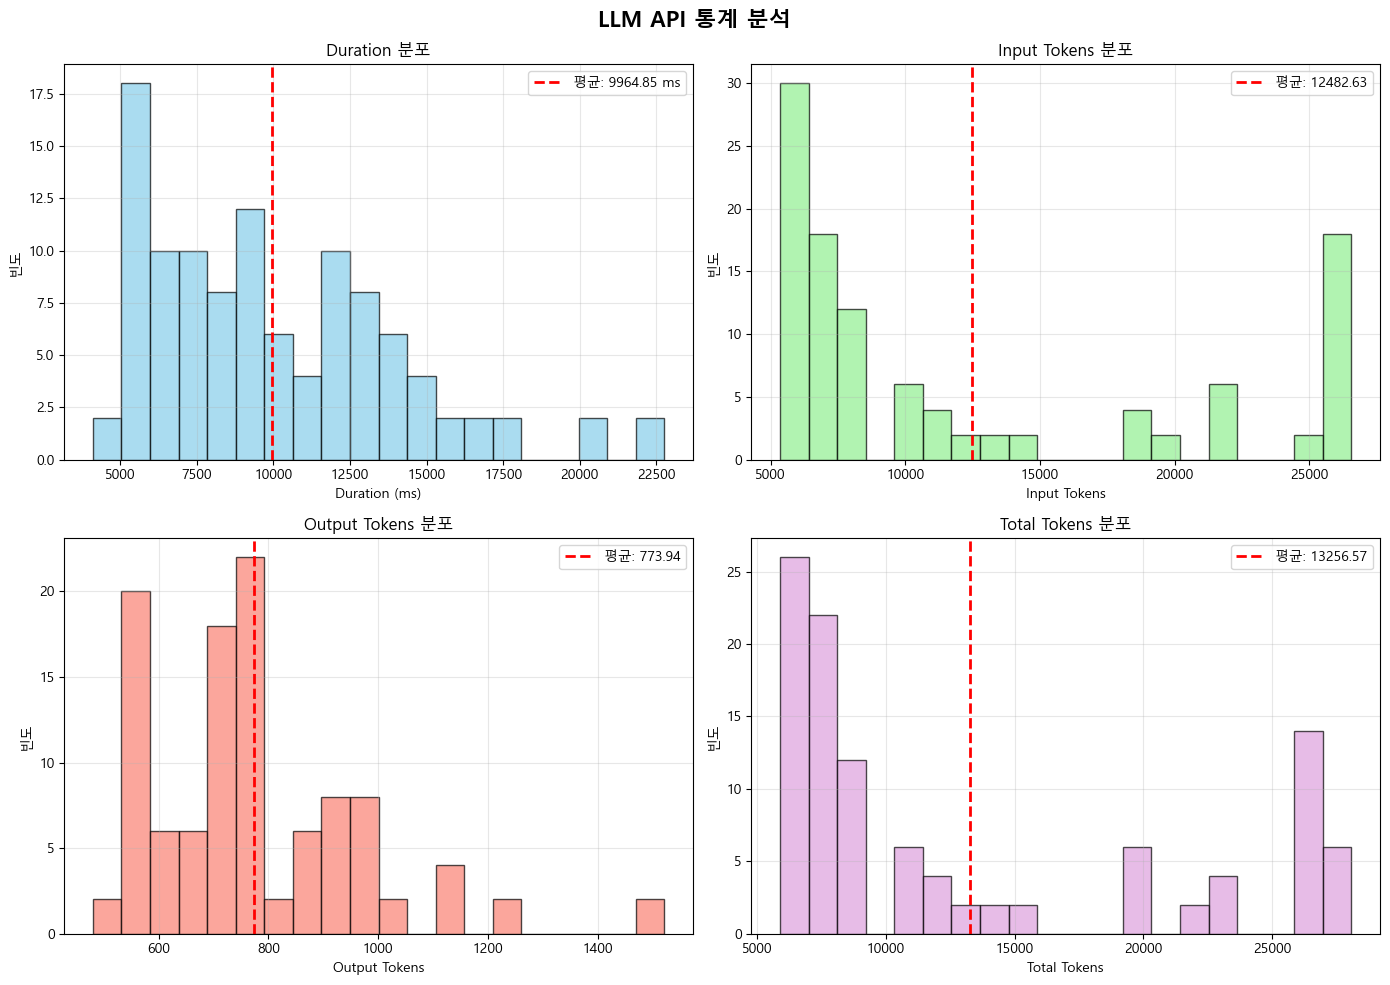

In [ ]:
# 시각화 - 히스토그램
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LLM API 통계 분석', fontsize=16, fontweight='bold')

# 1. Duration 히스토그램
if durations:
    axes[0, 0].hist(durations, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].axvline(avg_duration, color='red', linestyle='--', linewidth=2, label=f'평균: {avg_duration:.2f} ms')
    axes[0, 0].set_xlabel('Duration (ms)')
    axes[0, 0].set_ylabel('빈도')
    axes[0, 0].set_title('Duration 분포')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# 2. Input Tokens 히스토그램
if input_tokens:
    axes[0, 1].hist(input_tokens, bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[0, 1].axvline(avg_input_tokens, color='red', linestyle='--', linewidth=2, label=f'평균: {avg_input_tokens:.2f}')
    axes[0, 1].set_xlabel('Input Tokens')
    axes[0, 1].set_ylabel('빈도')
    axes[0, 1].set_title('Input Tokens 분포')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Output Tokens 히스토그램
if output_tokens:
    axes[1, 0].hist(output_tokens, bins=20, edgecolor='black', alpha=0.7, color='salmon')
    axes[1, 0].axvline(avg_output_tokens, color='red', linestyle='--', linewidth=2, label=f'평균: {avg_output_tokens:.2f}')
    axes[1, 0].set_xlabel('Output Tokens')
    axes[1, 0].set_ylabel('빈도')
    axes[1, 0].set_title('Output Tokens 분포')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 4. Total Tokens 히스토그램
if total_tokens:
    axes[1, 1].hist(total_tokens, bins=20, edgecolor='black', alpha=0.7, color='plum')
    axes[1, 1].axvline(avg_total_tokens, color='red', linestyle='--', linewidth=2, label=f'평균: {avg_total_tokens:.2f}')
    axes[1, 1].set_xlabel('Total Tokens')
    axes[1, 1].set_ylabel('빈도')
    axes[1, 1].set_title('Total Tokens 분포')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


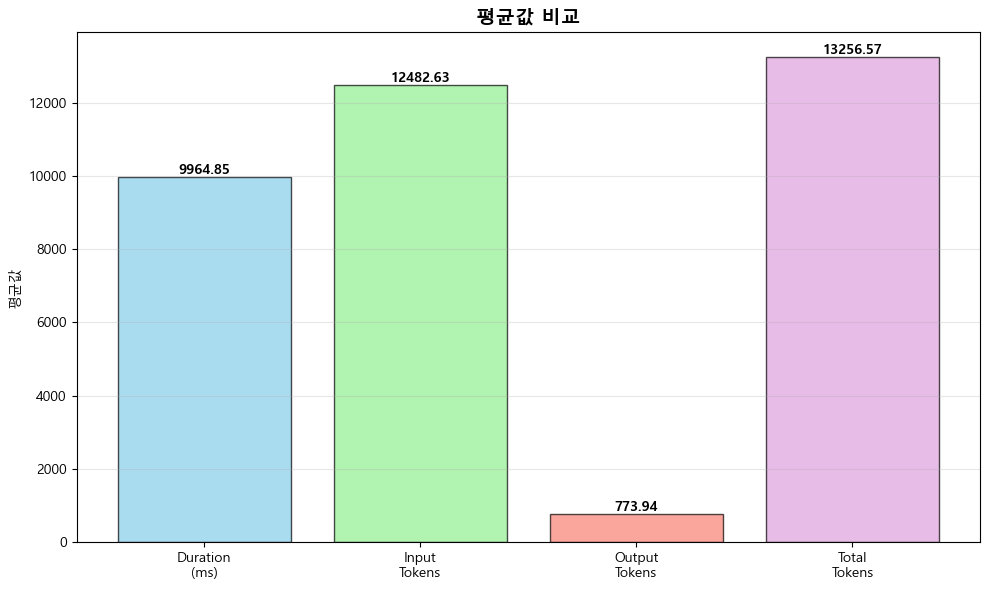

In [ ]:
# 평균값 비교 바 차트
fig2, ax = plt.subplots(figsize=(10, 6))
categories = ['Duration\n(ms)', 'Input\nTokens', 'Output\nTokens', 'Total\nTokens']
averages = [avg_duration, avg_input_tokens, avg_output_tokens, avg_total_tokens]
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

bars = ax.bar(categories, averages, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('평균값')
ax.set_title('평균값 비교', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 바 위에 값 표시
for i, (bar, avg) in enumerate(zip(bars, averages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{avg:.2f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
